## 1. Persiapan Library

In [1]:
import importlib.util
import subprocess
import sys

required_packages = ["xgboost", "catboost", "lightgbm"]
for package in required_packages:
    if importlib.util.find_spec(package) is None:
        print(f"Menginstal {package} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("Library siap digunakan.")


Library siap digunakan.


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 1

## 2. Membaca Dataset

In [3]:
df = pd.read_csv("Regresi 535250015.csv")

if "dteday" in df.columns:
    df["dteday"] = pd.to_datetime(df["dteday"])
    df = df.sort_values("dteday").reset_index(drop=True)

print("Dataset:")
print("Ukuran data:", df.shape)
display(df.head())

Dataset:
Ukuran data: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
print("Jumlah data:", len(df))
print("\nTipe data:")
display(df.dtypes.to_frame("dtype"))

Jumlah data: 731

Tipe data:


,dtype
instant,int64
dteday,datetime64[us]
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64


## 3. Menentukan Input dan Output

**Input (X):**
`season`, `weathersit`, `holiday`, `workingday`, `temp`, `atemp`, `hum`, `windspeed`

**Output/target (y):**
`cnt`


In [5]:
FEATURES = [
    "season",
    "weathersit",
    "holiday",
    "workingday",
    "temp",
    "atemp",
    "hum",
    "windspeed",
]
TARGET = "cnt"

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Input X:", FEATURES)
print("Output y:", TARGET)
print("Shape X:", X.shape)
print("Shape y:", y.shape)


Input X: ['season', 'weathersit', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed']
Output y: cnt
Shape X: (731, 8)
Shape y: (731,)


## 4. Konfigurasi Model


In [6]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE (%)": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "R2": r2_score(y_true, y_pred),
    }


def split_dataset(X, y, test_size):
    split_idx = int(len(X) * (1 - test_size))
    X_train = X.iloc[:split_idx].copy()
    X_test = X.iloc[split_idx:].copy()
    y_train = y.iloc[:split_idx].copy()
    y_test = y.iloc[split_idx:].copy()

    return X_train, X_test, y_train, y_test


def split_train_validation(X_train, y_train, val_size):
    split_idx = int(len(X_train) * (1 - val_size))
    X_subtrain = X_train.iloc[:split_idx].copy()
    X_val = X_train.iloc[split_idx:].copy()
    y_subtrain = y_train.iloc[:split_idx].copy()
    y_val = y_train.iloc[split_idx:].copy()
    
    return X_subtrain, X_val, y_subtrain, y_val


def build_base_models():
    return {
        "Linear Regression": LinearRegression(),
        "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "AdaBoost": AdaBoostRegressor(random_state=RANDOM_STATE),
        "XGBoost": XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
        "CatBoost": CatBoostRegressor(random_seed=RANDOM_STATE, verbose=0),
        "LightGBM": LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1),
    }


SVR_GRIDS = {
    "linear": {
        "C": [100, 1000, 5000],
        "epsilon": [0.1, 10, 50],
    },
    "rbf": {
        "C": [100, 1000, 5000],
        "epsilon": [0.1, 10, 50],
        "gamma": ["scale", 0.1, 1.0],
    },
    "poly": {
        "C": [100, 1000, 5000],
        "epsilon": [0.1, 10, 50],
        "degree": [2, 3],
        "gamma": ["scale"],
    },
}

SVR_LABELS = {
    "linear": "SVR Linear",
    "rbf": "SVR RBF",
    "poly": "SVR Polynomial",
}

MODEL_ORDER = [
    "Linear Regression",
    "Gradient Boosting",
    "AdaBoost",
    "XGBoost",
    "CatBoost",
    "LightGBM",
    "SVR Linear",
    "SVR RBF",
    "SVR Polynomial",
]


In [7]:
def tune_svr_kernel(kernel, X_train, y_train):
    X_subtrain, X_val, y_subtrain, y_val = split_train_validation(
        X_train, y_train, val_size=0.2
    )

    tuning_rows = []
    best_rmse = np.inf
    best_params = None

    for params in ParameterGrid(SVR_GRIDS[kernel]):
        model = make_pipeline(
            StandardScaler(),
            SVR(kernel=kernel, **params),
        )

        start = time.perf_counter()
        model.fit(X_subtrain, y_subtrain)
        tuning_time = time.perf_counter() - start

        val_pred = model.predict(X_val)
        val_metrics = regression_metrics(y_val, val_pred)

        tuning_rows.append({
            "Kernel": kernel,
            "Parameter": str(params),
            "Validation MAE": val_metrics["MAE"],
            "Validation RMSE": val_metrics["RMSE"],
            "Validation MAPE (%)": val_metrics["MAPE (%)"],
            "Validation R2": val_metrics["R2"],
            "Waktu Tuning (detik)": tuning_time,
        })

        if val_metrics["RMSE"] < best_rmse:
            best_rmse = val_metrics["RMSE"]
            best_params = params

    tuning_df = pd.DataFrame(tuning_rows).sort_values(
        "Validation RMSE", ascending=True
    ).reset_index(drop=True)

    return best_params, tuning_df


def run_scenario(test_size, scenario_name):
    X_train, X_test, y_train, y_test = split_dataset(X, y, test_size)

    print(f"{scenario_name}")
    print(f"Data latih: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
    print(f"Data uji  : {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

    result_rows = []
    predictions = {}
    tuning_tables = {}

    # 1) non-SVR
    for model_name, model in build_base_models().items():
        start = time.perf_counter()
        model.fit(X_train, y_train)
        train_time = time.perf_counter() - start

        y_pred = model.predict(X_test)
        m = regression_metrics(y_test, y_pred)

        result_rows.append({
            "Algoritma": model_name,
            "Nilai parameter kernel (khusus SVR)": "-",
            "MAE": m["MAE"],
            "RMSE": m["RMSE"],
            "MAPE (%)": m["MAPE (%)"],
            "R2": m["R2"],
            "Waktu Pelatihan (detik)": train_time,
        })
        predictions[model_name] = y_pred

    # 2) SVR
    for kernel in ["linear", "rbf", "poly"]:
        best_params, tuning_df = tune_svr_kernel(kernel, X_train, y_train)
        tuning_tables[kernel] = tuning_df

        best_model = make_pipeline(
            StandardScaler(),
            SVR(kernel=kernel, **best_params),
        )

        start = time.perf_counter()
        best_model.fit(X_train, y_train)
        train_time = time.perf_counter() - start

        y_pred = best_model.predict(X_test)
        m = regression_metrics(y_test, y_pred)

        model_name = SVR_LABELS[kernel]
        result_rows.append({
            "Algoritma": model_name,
            "Nilai parameter kernel (khusus SVR)": str(best_params),
            "MAE": m["MAE"],
            "RMSE": m["RMSE"],
            "MAPE (%)": m["MAPE (%)"],
            "R2": m["R2"],
            "Waktu Pelatihan (detik)": train_time,
        })
        predictions[model_name] = y_pred

    results = pd.DataFrame(result_rows)
    results["Algoritma"] = pd.Categorical(
        results["Algoritma"], categories=MODEL_ORDER, ordered=True
    )
    results = results.sort_values("Algoritma").reset_index(drop=True)
    results["Algoritma"] = results["Algoritma"].astype(str)

    return {
        "results": results,
        "predictions": predictions,
        "tuning": tuning_tables,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
    }


def show_result_table(results):
    display(
        results.style.format({
            "MAE": "{:.4f}",
            "RMSE": "{:.4f}",
            "MAPE (%)": "{:.4f}",
            "R2": "{:.4f}",
            "Waktu Pelatihan (detik)": "{:.6f}",
        })
    )


def plot_predictions(scenario, title, save_name):
    X_test = scenario["X_test"]
    y_test = scenario["y_test"]
    predictions = scenario["predictions"]

    ordered_index = sorted(X_test.index)
    pos_map = {idx: pos for pos, idx in enumerate(X_test.index)}
    ordered_positions = [pos_map[idx] for idx in ordered_index]

    y_actual_ordered = y_test.loc[ordered_index].to_numpy()

    if "dteday" in df.columns:
        x_axis = df.loc[ordered_index, "dteday"].to_numpy()
        x_label = "Tanggal"
    else:
        x_axis = np.arange(len(ordered_index))
        x_label = "Urutan data uji"

    plt.figure(figsize=(16, 8))
    plt.plot(
        x_axis,
        y_actual_ordered,
        label="Aktual",
        linewidth=3,
    )

    for model_name in MODEL_ORDER:
        pred_ordered = np.asarray(predictions[model_name])[ordered_positions]
        plt.plot(
            x_axis,
            pred_ordered,
            label=model_name,
            alpha=0.75,
            linewidth=1.2,
        )

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel("Jumlah penyewaan sepeda (cnt)")
    plt.legend(ncol=2)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(save_name, dpi=180, bbox_inches="tight")
    plt.show()


# 4. Hasil Eksperimen

## Skenario 1 — Data latih 70%, data uji 30%


In [8]:
scenario_70_30 = run_scenario(
    test_size=0.30,
    scenario_name="Skenario 1: 70% train - 30% test",
)

results_70_30 = scenario_70_30["results"]
show_result_table(results_70_30)


Skenario 1: 70% train - 30% test
Data latih: 511 (69.9%)
Data uji  : 220 (30.1%)


,Algoritma,Nilai parameter kernel (khusus SVR),MAE,RMSE,MAPE (%),R2,Waktu Pelatihan (detik)
0,Linear Regression,-,1951.4362,2183.9700,81.9769,-0.7491,0.028481
1,Gradient Boosting,-,1988.2653,2132.3025,65.1819,-0.6673,0.091512
2,AdaBoost,-,2037.3639,2199.3575,83.0072,-0.7738,0.089278
3,XGBoost,-,1991.0568,2149.4856,91.2508,-0.6943,0.195403
4,CatBoost,-,1995.9722,2140.1964,69.9532,-0.6797,1.335066
5,LightGBM,-,2029.6850,2185.0238,76.3737,-0.7508,0.031878
6,SVR Linear,"{'C': 100, 'epsilon': 0.1}",1927.8280,2124.1365,77.6691,-0.6545,0.011893
7,SVR RBF,"{'C': 5000, 'epsilon': 0.1, 'gamma': 'scale'}",2017.9619,2170.7933,80.9580,-0.7280,0.024333
8,SVR Polynomial,"{'C': 1000, 'degree': 2, 'epsilon': 10, 'gamma': 'scale'}",2507.2473,2758.7983,46.1251,-1.7910,0.013611


### Parameter SVR — Skenario 1

In [9]:
for kernel_name in ["linear", "rbf", "poly"]:
    print(f"\nSVR kernel = {kernel_name}")
    display(
        scenario_70_30["tuning"][kernel_name].style.format({
            "Validation MAE": "{:.4f}",
            "Validation RMSE": "{:.4f}",
            "Validation MAPE (%)": "{:.4f}",
            "Validation R2": "{:.4f}",
            "Waktu Tuning (detik)": "{:.6f}",
        })
    )



SVR kernel = linear


,Kernel,Parameter,Validation MAE,Validation RMSE,Validation MAPE (%),Validation R2,Waktu Tuning (detik)
0,linear,"{'C': 100, 'epsilon': 0.1}",2234.9335,2401.1944,40.1983,-1.7597,0.011567
1,linear,"{'C': 100, 'epsilon': 10}",2237.4370,2403.0437,40.2569,-1.7639,0.010634
2,linear,"{'C': 1000, 'epsilon': 10}",2238.7425,2403.8161,40.2776,-1.7657,0.019899
3,linear,"{'C': 1000, 'epsilon': 0.1}",2238.4390,2404.5888,40.2528,-1.7675,0.016382
4,linear,"{'C': 100, 'epsilon': 50}",2243.3395,2407.5945,40.3744,-1.7744,0.009484
5,linear,"{'C': 5000, 'epsilon': 0.1}",2244.2302,2411.1773,40.3355,-1.7827,0.033731
6,linear,"{'C': 5000, 'epsilon': 10}",2247.9116,2414.5193,40.4144,-1.7904,0.058983
7,linear,"{'C': 1000, 'epsilon': 50}",2257.5485,2421.7487,40.6175,-1.8071,0.015118
8,linear,"{'C': 5000, 'epsilon': 50}",2292.2957,2457.3825,41.2664,-1.8903,0.051827



SVR kernel = rbf


,Kernel,Parameter,Validation MAE,Validation RMSE,Validation MAPE (%),Validation R2,Waktu Tuning (detik)
0,rbf,"{'C': 5000, 'epsilon': 0.1, 'gamma': 'scale'}",1849.8041,2021.4460,33.5044,-0.9558,0.020837
1,rbf,"{'C': 5000, 'epsilon': 10, 'gamma': 'scale'}",1853.6629,2024.9224,33.5737,-0.9625,0.017736
2,rbf,"{'C': 1000, 'epsilon': 10, 'gamma': 0.1}",1877.0314,2025.5604,34.2560,-0.9638,0.009719
3,rbf,"{'C': 1000, 'epsilon': 0.1, 'gamma': 0.1}",1878.2491,2026.4143,34.2785,-0.9654,0.009973
4,rbf,"{'C': 5000, 'epsilon': 0.1, 'gamma': 0.1}",1865.0362,2027.8501,33.9021,-0.9682,0.020160
5,rbf,"{'C': 5000, 'epsilon': 50, 'gamma': 0.1}",1867.3522,2029.4868,33.8921,-0.9714,0.014274
6,rbf,"{'C': 5000, 'epsilon': 10, 'gamma': 0.1}",1867.2228,2029.9747,33.9246,-0.9723,0.016968
7,rbf,"{'C': 1000, 'epsilon': 50, 'gamma': 0.1}",1885.1544,2034.5398,34.3747,-0.9812,0.009377
8,rbf,"{'C': 1000, 'epsilon': 0.1, 'gamma': 'scale'}",1886.1433,2036.4885,34.4623,-0.9850,0.010833
9,rbf,"{'C': 1000, 'epsilon': 10, 'gamma': 'scale'}",1888.1766,2039.1500,34.4843,-0.9902,0.010022



SVR kernel = poly


,Kernel,Parameter,Validation MAE,Validation RMSE,Validation MAPE (%),Validation R2,Waktu Tuning (detik)
0,poly,"{'C': 1000, 'degree': 2, 'epsilon': 10, 'gamma': 'scale'}",1578.4940,1846.4836,27.7318,-0.6319,0.009940
1,poly,"{'C': 1000, 'degree': 2, 'epsilon': 50, 'gamma': 'scale'}",1584.5720,1847.0388,27.9234,-0.6329,0.008693
2,poly,"{'C': 1000, 'degree': 2, 'epsilon': 0.1, 'gamma': 'scale'}",1583.8523,1850.8591,27.8206,-0.6396,0.010761
3,poly,"{'C': 5000, 'degree': 2, 'epsilon': 0.1, 'gamma': 'scale'}",1572.3457,1862.8012,27.8584,-0.6609,0.038591
4,poly,"{'C': 5000, 'degree': 2, 'epsilon': 10, 'gamma': 'scale'}",1574.7070,1868.0272,27.9057,-0.6702,0.025775
5,poly,"{'C': 5000, 'degree': 2, 'epsilon': 50, 'gamma': 'scale'}",1584.6403,1880.4075,28.0909,-0.6924,0.014721
6,poly,"{'C': 100, 'degree': 2, 'epsilon': 10, 'gamma': 'scale'}",1762.6692,2019.7216,31.6771,-0.9525,0.005702
7,poly,"{'C': 100, 'degree': 2, 'epsilon': 0.1, 'gamma': 'scale'}",1764.5846,2022.0213,31.6784,-0.9569,0.007181
8,poly,"{'C': 100, 'degree': 2, 'epsilon': 50, 'gamma': 'scale'}",1775.3081,2032.4702,31.8877,-0.9772,0.006967
9,poly,"{'C': 5000, 'degree': 3, 'epsilon': 50, 'gamma': 'scale'}",1889.3194,2072.9804,34.0958,-1.0568,0.053888


### Grafik perbandingan nilai sebenarnya dan nilai hasil prediksi untuk skenario 1


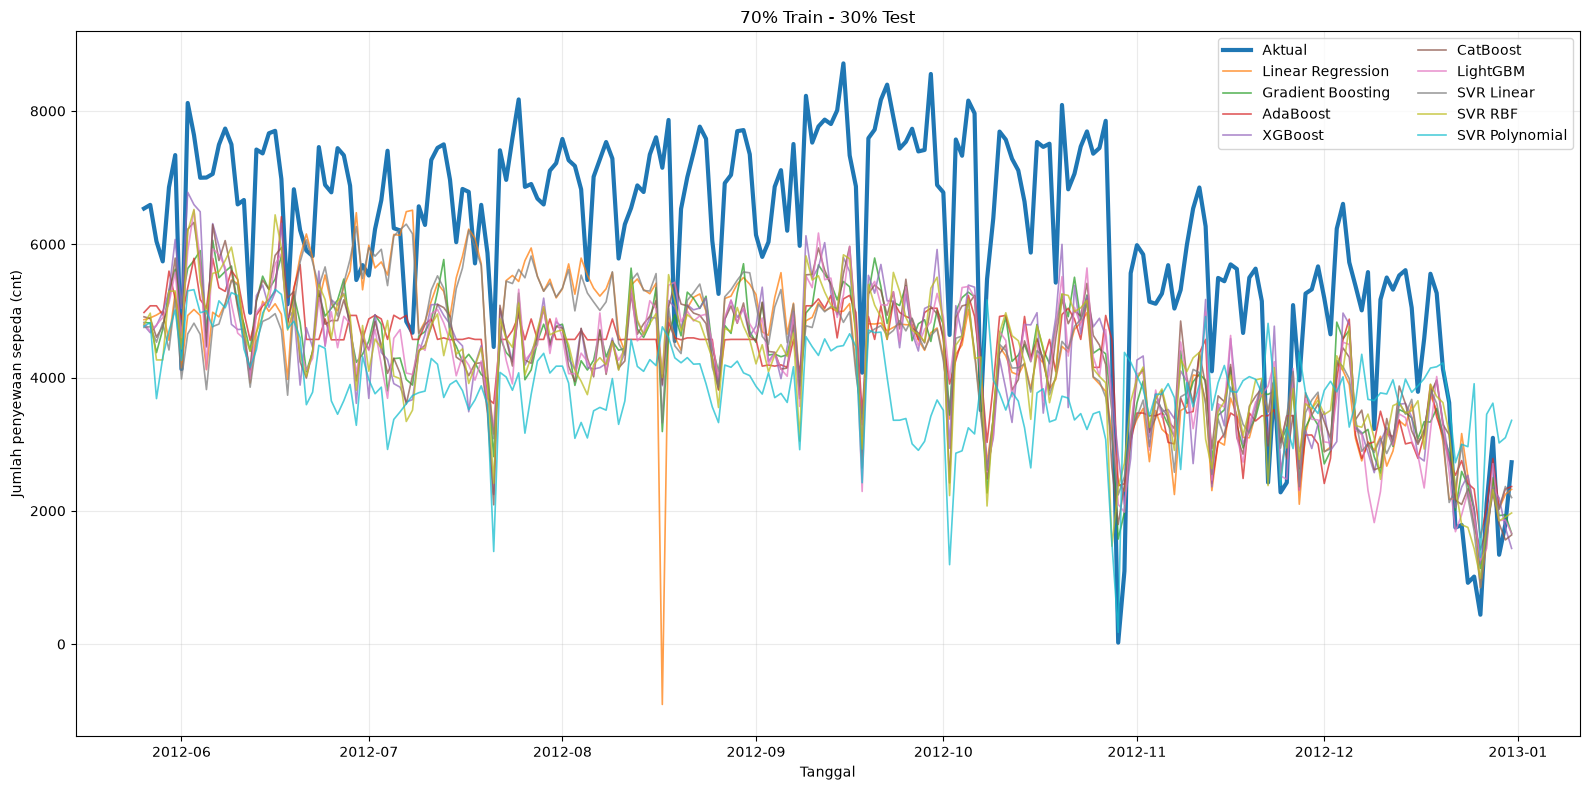

In [10]:
plot_predictions(
    scenario_70_30,
    title="70% Train - 30% Test",
    save_name="grafik_skenario_70_30.png",
)


## Skenario 2 — Data latih 80%, data uji 20%


In [11]:
scenario_80_20 = run_scenario(
    test_size=0.20,
    scenario_name="Skenario 2: 80% train - 20% test",
)

results_80_20 = scenario_80_20["results"]
show_result_table(results_80_20)


Skenario 2: 80% train - 20% test
Data latih: 584 (79.9%)
Data uji  : 147 (20.1%)


,Algoritma,Nilai parameter kernel (khusus SVR),MAE,RMSE,MAPE (%),R2,Waktu Pelatihan (detik)
0,Linear Regression,-,2014.7143,2212.5185,106.3670,-0.3930,0.003053
1,Gradient Boosting,-,1878.4534,2039.9368,94.7038,-0.1842,0.108236
2,AdaBoost,-,1722.8510,1882.0627,131.9553,-0.0080,0.069478
3,XGBoost,-,1850.5868,2065.8755,115.6638,-0.2145,0.227432
4,CatBoost,-,1897.4926,2083.7655,89.2113,-0.2356,1.134103
5,LightGBM,-,1900.9298,2101.4835,87.7806,-0.2567,0.024056
6,SVR Linear,"{'C': 5000, 'epsilon': 50}",1991.9489,2202.3872,108.1987,-0.3803,0.089830
7,SVR RBF,"{'C': 1000, 'epsilon': 0.1, 'gamma': 'scale'}",2010.4039,2178.4659,101.4421,-0.3504,0.017618
8,SVR Polynomial,"{'C': 1000, 'degree': 3, 'epsilon': 10, 'gamma': 'scale'}",1995.5749,2227.9586,58.5309,-0.4125,0.023071


### Parameter SVR — Skenario 2


In [12]:
for kernel_name in ["linear", "rbf", "poly"]:
    print(f"\nSVR kernel = {kernel_name}")
    display(
        scenario_80_20["tuning"][kernel_name].style.format({
            "Validation MAE": "{:.4f}",
            "Validation RMSE": "{:.4f}",
            "Validation MAPE (%)": "{:.4f}",
            "Validation R2": "{:.4f}",
            "Waktu Tuning (detik)": "{:.6f}",
        })
    )



SVR kernel = linear


,Kernel,Parameter,Validation MAE,Validation RMSE,Validation MAPE (%),Validation R2,Waktu Tuning (detik)
0,linear,"{'C': 5000, 'epsilon': 50}",1911.5114,2078.0224,29.5486,-2.4207,0.115619
1,linear,"{'C': 5000, 'epsilon': 10}",1916.6721,2083.4657,29.6212,-2.4386,0.054036
2,linear,"{'C': 5000, 'epsilon': 0.1}",1922.6580,2089.9956,29.7033,-2.4602,0.048409
3,linear,"{'C': 1000, 'epsilon': 0.1}",1922.9505,2092.8367,29.6724,-2.4696,0.024870
4,linear,"{'C': 1000, 'epsilon': 10}",1924.5940,2094.4267,29.6852,-2.4749,0.021337
5,linear,"{'C': 1000, 'epsilon': 50}",1927.2864,2097.3573,29.7377,-2.4846,0.035650
6,linear,"{'C': 100, 'epsilon': 50}",1943.0778,2119.3946,29.9064,-2.5582,0.016231
7,linear,"{'C': 100, 'epsilon': 0.1}",1963.9079,2139.8825,30.2195,-2.6274,0.017150
8,linear,"{'C': 100, 'epsilon': 10}",1965.0472,2140.4742,30.2313,-2.6294,0.011178



SVR kernel = rbf


,Kernel,Parameter,Validation MAE,Validation RMSE,Validation MAPE (%),Validation R2,Waktu Tuning (detik)
0,rbf,"{'C': 1000, 'epsilon': 0.1, 'gamma': 'scale'}",1892.4463,2023.9949,28.9511,-2.2451,0.012036
1,rbf,"{'C': 1000, 'epsilon': 10, 'gamma': 'scale'}",1894.0245,2025.4731,28.9751,-2.2499,0.013786
2,rbf,"{'C': 1000, 'epsilon': 0.1, 'gamma': 0.1}",1896.1501,2026.4951,28.9616,-2.2531,0.013573
3,rbf,"{'C': 1000, 'epsilon': 10, 'gamma': 0.1}",1896.6578,2027.0272,28.9737,-2.2548,0.013545
4,rbf,"{'C': 1000, 'epsilon': 50, 'gamma': 'scale'}",1903.8336,2036.9769,29.0894,-2.2869,0.012960
5,rbf,"{'C': 1000, 'epsilon': 50, 'gamma': 0.1}",1908.4278,2039.4658,29.1243,-2.2949,0.013180
6,rbf,"{'C': 5000, 'epsilon': 50, 'gamma': 0.1}",1919.5063,2054.7089,29.1152,-2.3444,0.018577
7,rbf,"{'C': 5000, 'epsilon': 50, 'gamma': 'scale'}",1917.4120,2056.5189,29.0567,-2.3502,0.019046
8,rbf,"{'C': 5000, 'epsilon': 0.1, 'gamma': 0.1}",1923.0525,2058.3586,29.2103,-2.3562,0.020296
9,rbf,"{'C': 5000, 'epsilon': 10, 'gamma': 0.1}",1926.0799,2061.7745,29.2421,-2.3674,0.019427



SVR kernel = poly


,Kernel,Parameter,Validation MAE,Validation RMSE,Validation MAPE (%),Validation R2,Waktu Tuning (detik)
0,poly,"{'C': 1000, 'degree': 3, 'epsilon': 10, 'gamma': 'scale'}",2121.8973,2300.4898,32.2717,-3.1923,0.016339
1,poly,"{'C': 1000, 'degree': 3, 'epsilon': 50, 'gamma': 'scale'}",2121.4564,2301.1956,32.1833,-3.1949,0.016959
2,poly,"{'C': 1000, 'degree': 3, 'epsilon': 0.1, 'gamma': 'scale'}",2123.5279,2302.9454,32.2749,-3.2013,0.018939
3,poly,"{'C': 100, 'degree': 3, 'epsilon': 50, 'gamma': 'scale'}",2181.3210,2372.9349,33.0758,-3.4605,0.008263
4,poly,"{'C': 100, 'degree': 3, 'epsilon': 0.1, 'gamma': 'scale'}",2199.9650,2389.3899,33.3676,-3.5226,0.009262
5,poly,"{'C': 100, 'degree': 3, 'epsilon': 10, 'gamma': 'scale'}",2200.1077,2389.8911,33.3740,-3.5245,0.009603
6,poly,"{'C': 1000, 'degree': 2, 'epsilon': 0.1, 'gamma': 'scale'}",2264.5894,2463.8969,34.4703,-3.8090,0.027705
7,poly,"{'C': 1000, 'degree': 2, 'epsilon': 10, 'gamma': 'scale'}",2267.1229,2465.3459,34.4631,-3.8147,0.029593
8,poly,"{'C': 1000, 'degree': 2, 'epsilon': 50, 'gamma': 'scale'}",2267.2096,2465.3987,34.4052,-3.8149,0.026973
9,poly,"{'C': 5000, 'degree': 2, 'epsilon': 0.1, 'gamma': 'scale'}",2202.9997,2471.4550,33.2965,-3.8386,0.034327


### Grafik perbandingan nilai sebenarnya dan nilai hasil prediksi untuk skenario 2


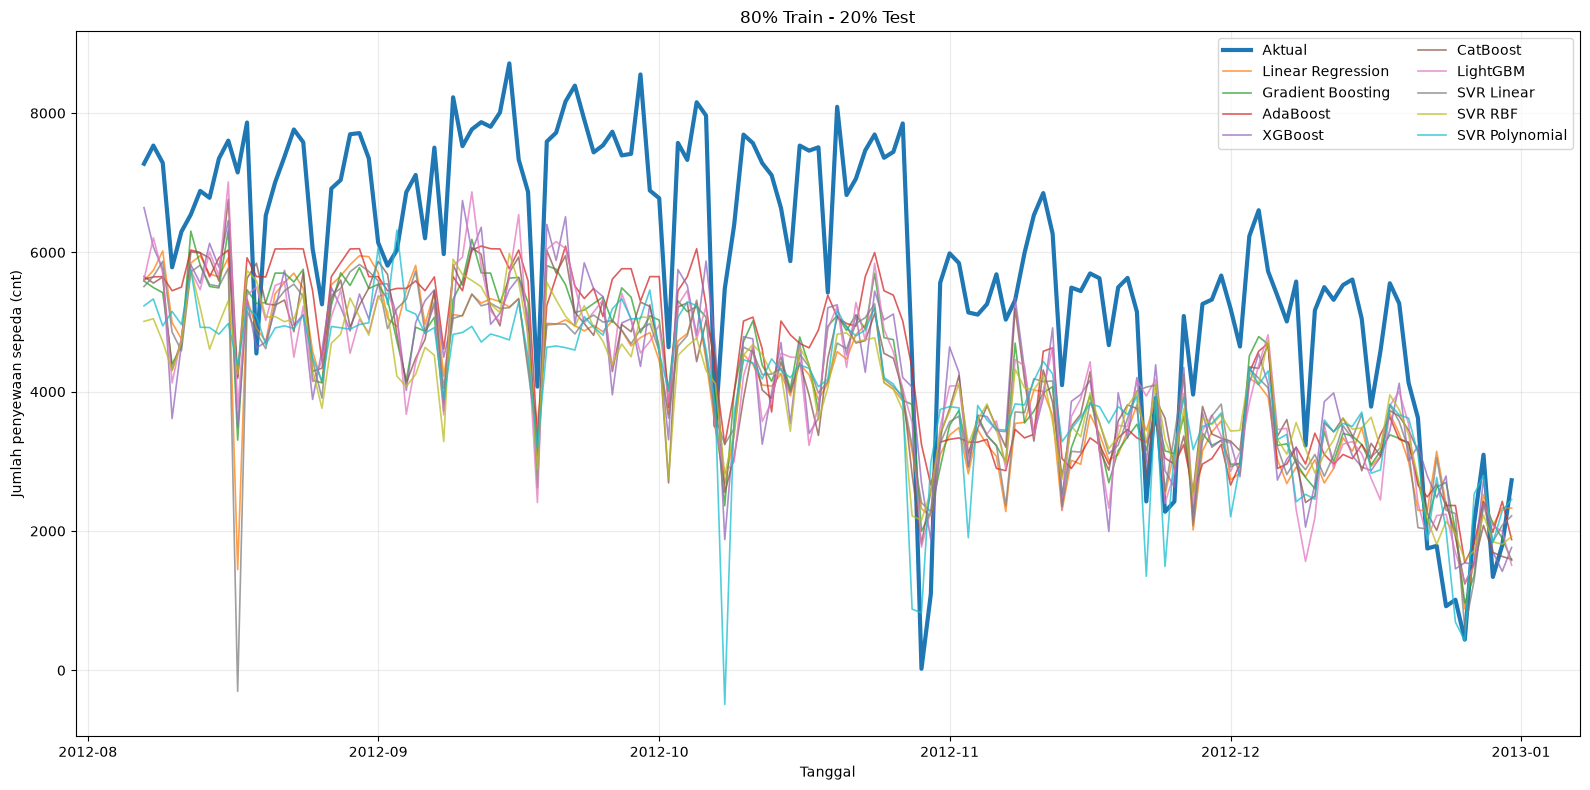

In [13]:
plot_predictions(
    scenario_80_20,
    title="80% Train - 20% Test",
    save_name="grafik_skenario_80_20.png",
)
